In [112]:
import matplotlib.pyplot as plt
import numpy as np

Data

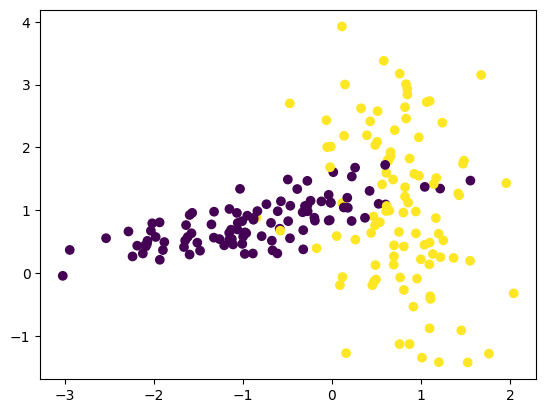

In [113]:
from sklearn.datasets import make_classification
X,y= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
K = 4

plt.figure()
plt.scatter  (X[:,0], X[:,1], c =y)

In [114]:
def init_centroids(X: np.ndarray, K=4):
    n_features = X.shape[1]
    
    centroids = []
    for _ in range(K):
        centroid = []
        for i in range(n_features): #In theory that will work with multidimensional data
            f_min = X[:, i].min()
            f_max = X[:, i].max()
            centroid.append(np.random.uniform(f_min, f_max))
        centroids.append(centroid)
    return np.array(centroids)

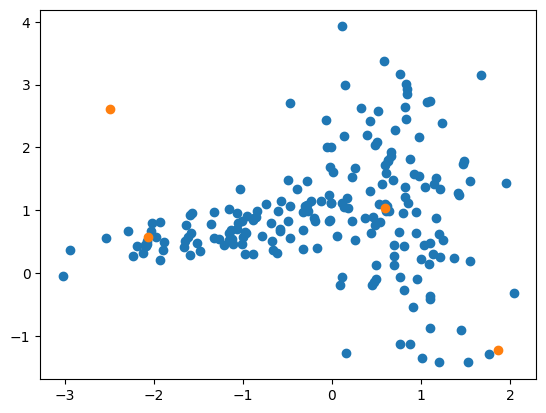

In [115]:
centroids = init_centroids(X)
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1])

In [116]:
def assign_to_centroid(X: np.ndarray, centroids: np.ndarray):
    y = []
    y_centroid = []
    for point in X:
        clossest = (float('inf'), None, None)
        for i in range(len(centroids)):
            distance = np.sum((point-centroids[i])**2) #we are not computing square root, because we only need correct comparison, and not correct distance
            if clossest[0] > distance:
                clossest = (distance, i, centroids[i])
        y.append(clossest[1])
        y_centroid.append(clossest[2])
    return np.array(y), np.array(y_centroid)
        

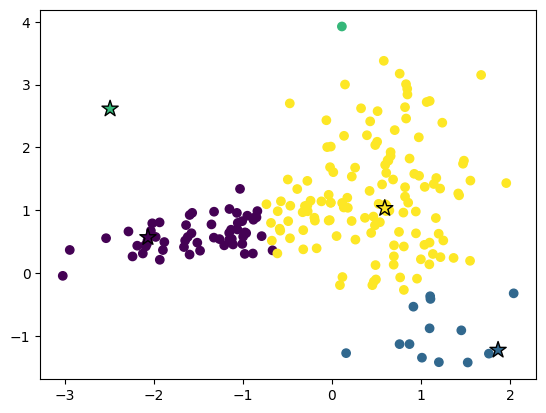

In [117]:
y_pred, y_centroid = assign_to_centroid(X, centroids)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", c=list(range(len(centroids))), edgecolors="Black", s=150)

In [125]:
def compute_new_centroids(X, y):
    centroids = []
    for i in range(K):
        if X[y==i].shape[0] == 0:
            continue
        centroids.append(X[y==i].mean(axis=0))
    return np.array(centroids)

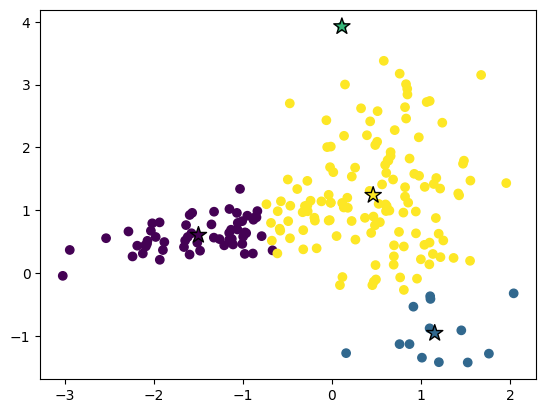

In [119]:
centroids = compute_new_centroids(X, y_pred)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", c=list(range(len(centroids))), edgecolors="Black", s=150)

In [120]:
def J(X, y_centroid):
    m = X.shape[0]

    loss = np.sum((np.linalg.norm(X-y_centroid)**2))/ m
    return loss

In [121]:
print(J(X, y_centroid))

1.0163125310226435


Now that we know everything work, we can start on making the whole pipeline

k_mean №0, loss = 0.5638732958611394
k_mean №1, loss = 0.5104949893995362
k_mean №4, loss = 0.4644025713483872


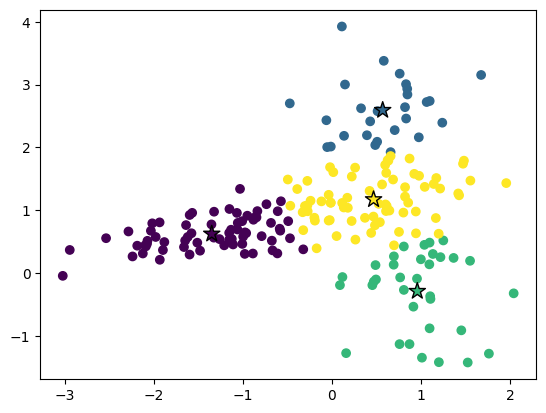

In [128]:
K = 4
NUM_K_MEANS = 100
NUM_EPOCHS = 4

best_k_means = (None, float('+inf'))
for k_mean in range(NUM_K_MEANS):
    centroids = init_centroids(X, K=K)
    for epoch in range(NUM_EPOCHS):
        y_pred, y_centroid = assign_to_centroid(X, centroids)
        centroids = compute_new_centroids(X, y_pred)
    loss = J(X, y_centroid)
    if loss < best_k_means[1]:
        best_k_means = (centroids, loss)
        print(f"k_mean №{k_mean}, loss = {loss}")

centroids = best_k_means[0]
y_pred, y_centroid = assign_to_centroid(X, centroids)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="*", c=list(range(len(centroids))), edgecolors="Black", s=150)